# Step 14: Simplified Regime Filtering (Noise Reduction)

## 🎯 Objective:
Meningkatkan akurasi prediksi rezim dengan cara menghilangkan "noise" menggunakan **PCA**.

## 🛠️ Fix Applied:
Menambahkan penanganan **NaN** dan **Infinite** values yang sering muncul pada data koin yang baru melantai (newly listed) agar tidak merusak proses Scaling.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ Noise reduction tools ready!")

✅ Noise reduction tools ready!


## 1. Robust Data Cleaning & PCA

In [4]:
# 1. Load Data
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change()

# 2. Handle NaN/Inf (PENTING)
returns = returns.replace([np.inf, -np.inf], np.nan).fillna(0)

# 3. Bersihkan data (Hapus hari pertama yang pasti NaN)
returns = returns.iloc[1:]

print(f"📊 Data Cleaned. Shape: {returns.shape}")
print(f"🔍 Missing values left: {returns.isnull().sum().sum()}")

# 4. Standardize
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)

# 5. PCA Extraction
pca = PCA(n_components=5)
pca_factors = pca.fit_transform(returns_scaled)
df_pca = pd.DataFrame(pca_factors, index=returns.index, columns=[f'PC{i+1}' for i in range(5)])

print(f"\n📈 PCA Explained Variance (PC1): {pca.explained_variance_ratio_[0]:.2%}")

📊 Data Cleaned. Shape: (989, 24)
🔍 Missing values left: 0

📈 PCA Explained Variance (PC1): 42.82%


## 2. Model Training (PCA vs Target)

In [5]:
btc_ret = returns['BTC-USD']
threshold = 0.005
y_raw = np.where(btc_ret.shift(-1) > threshold, 1, np.where(btc_ret.shift(-1) < -threshold, 0, np.nan))
y_series = pd.Series(y_raw, index=btc_ret.index)

X_clean = df_pca.copy()
X_clean['BTC_Vol'] = btc_ret.rolling(20).std()
X_clean['Actual'] = y_series
X_clean = X_clean.dropna()

y_final = X_clean['Actual']
X_final = X_clean.drop(columns=['Actual'])

X_train = X_final[X_final.index.year < 2025]
y_train = y_final[y_final.index.year < 2025]
X_test = X_final[X_final.index.year == 2025]
y_test = y_final[y_final.index.year == 2025]

clean_model = xgb.XGBClassifier(random_state=42, n_estimators=100, learning_rate=0.05, eval_metric='logloss')
clean_model.fit(X_train, y_train)

y_pred = clean_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"🏆 Simplified Model Accuracy (2025): {acc:.2%}")

🏆 Simplified Model Accuracy (2025): 53.93%


## 3. Visualization

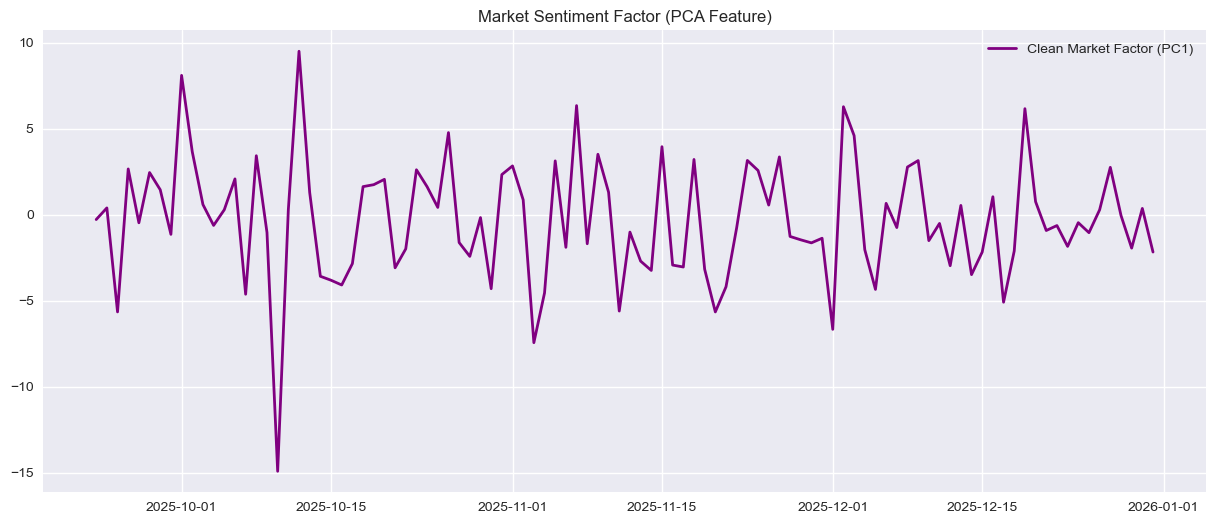

In [6]:
plt.figure(figsize=(15, 6))
plt.plot(df_pca.index[-100:], df_pca['PC1'].tail(100), label='Clean Market Factor (PC1)', color='purple', lw=2)
plt.title('Market Sentiment Factor (PCA Feature)')
plt.legend()
plt.show()